In order for the dataloader to not break, we need to associate with the patterns some structure, even if that structure is not the correct one. However, if we want to use things like fixing atom types or num atoms, we should choose structures that have the right number of atoms and the right stoichiometric ratios, then substitute in Ti Bi atoms to get model-interpretable information 

In [ ]:
import pandas as pd

In [40]:
def count_atomic_numbers(atomic_numbers_list):
    """Takes a list of atomic numbers and returns a dictionary with counts of each atomic number."""
    counts_dict = {}
    for number in atomic_numbers_list:
        if number in counts_dict:
            counts_dict[number] += 1
        else:
            counts_dict[number] = 1
    return counts_dict

def filter_dictionaries_by_ratio(dictionaries, ratio_list = []):
    """Filters dictionaries to find those with two entries that have a 1:3 ratio."""
    result = []
    indices = []    
    for d in dictionaries:
        # Check if the dictionary has exactly two keys and the ratios match 1:3
        if len(d) == 2:
            keys = list(d.keys())
            values = list(d.values())
            ratio = values[0] / values[1]
            # Check ratios 1:3, 2:6, 3:9, 4:12, 5:15 (all equivalent to 1:3 when simplified)
            if ratio in ratio_list:
                result.append(d)
                indices.append(dictionaries.index(d))
    return result, indices

def print_first_distinct_sums(dictionaries, Ti3Bi_indices):
    """
    Goes through a list of dictionaries, prints out the first instance of each distinct sum of the values
    (which are multiples of 4), and prints out the indices as well.
    """
    encountered_sums = {}  # Dictionary to track encountered sums and their first index
    list_of_indices = []
    for i, d in enumerate(dictionaries):
        current_sum = sum(d.values())
        
        # Check if the sum is a multiple of 4 and hasn't been encountered before
        if current_sum not in encountered_sums:
            encountered_sums[current_sum] = i  # Store the index of the first occurrence
            print(f"Index: {i}, Sum: {current_sum}, Dictionary: {d}")
            print(f"Index in original list: {Ti3Bi_indices[i]}")
            list_of_indices.append(Ti3Bi_indices[i])
    return list_of_indices

In [41]:
import ast

In [42]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20_final/test.csv")
test_df['atomic_numbers'] = test_df['atomic_numbers'].apply(ast.literal_eval)
test_df['counts_dict'] = test_df['atomic_numbers'].apply(count_atomic_numbers)
dicts = test_df['counts_dict'].tolist()
Ti3Bi_filtered_dicts, Ti3Bi_indices = filter_dictionaries_by_ratio(dicts, [1/3, 3])
Ti3Bi_indices = print_first_distinct_sums(Ti3Bi_filtered_dicts, Ti3Bi_indices)

Index: 0, Sum: 4, Dictionary: {26: 3, 78: 1}
Index in original list: 14
Index: 1, Sum: 16, Dictionary: {50: 12, 46: 4}
Index in original list: 23
Index: 4, Sum: 20, Dictionary: {65: 5, 13: 15}
Index in original list: 92
Index: 6, Sum: 12, Dictionary: {60: 3, 28: 9}
Index in original list: 115
Index: 10, Sum: 8, Dictionary: {47: 6, 79: 2}
Index in original list: 173


In [43]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20_final/test.csv")
test_df['atomic_numbers'] = test_df['atomic_numbers'].apply(ast.literal_eval)
test_df['counts_dict'] = test_df['atomic_numbers'].apply(count_atomic_numbers)
dicts = test_df['counts_dict'].tolist()
# Filter dictionaries by ratio
Ti3Bi2_filtered_dicts, Ti3Bi2_indices = filter_dictionaries_by_ratio(dicts, [2/3, 3/2])
Ti3Bi2_indices = print_first_distinct_sums(Ti3Bi2_filtered_dicts, Ti3Bi2_indices)

Index: 0, Sum: 5, Dictionary: {56: 2, 83: 3}
Index in original list: 19
Index: 1, Sum: 20, Dictionary: {68: 8, 16: 12}
Index in original list: 332
Index: 2, Sum: 10, Dictionary: {65: 6, 28: 4}
Index in original list: 591
Index: 6, Sum: 15, Dictionary: {57: 6, 8: 9}
Index in original list: 903


In [44]:
# use the Ti3Bi_indices and Ti3Bi2_indices to filter the test.csv file into two separate dataframes
Ti3Bi_df = test_df.iloc[Ti3Bi_indices]
Ti3Bi2_df = test_df.iloc[Ti3Bi2_indices]

#add in the xrd data
Ti3Bi2_xrds = pd.read_csv('/home/gridsan/tmackey/cdvae/scripts/1-31-2024_clean_implementations_unsolved_compounds/Unsolved_Compounds/Ti3Bi2_intensity_position.txt', delimiter = '\t', header = None)
Ti3Bi_xrds = pd.read_csv('/home/gridsan/tmackey/cdvae/scripts/1-31-2024_clean_implementations_unsolved_compounds/Unsolved_Compounds/Ti3Bi_Intensity_Positions.txt', delimiter = '\t', header = None)

#add columns for xrd_peak_locations and xrd_peak_intensities
Ti3Bi_df['xrd_peak_locations'] = len(Ti3Bi_df) * [list(Ti3Bi_xrds[1])]
Ti3Bi_df['xrd_peak_intensities'] = len(Ti3Bi_df) * [list(Ti3Bi_xrds[3])]
Ti3Bi2_df['xrd_peak_locations'] = len(Ti3Bi2_df) * [list(Ti3Bi2_xrds[1])]
Ti3Bi2_df['xrd_peak_intensities'] = len(Ti3Bi2_df) *[ list(Ti3Bi2_xrds[3])]

#make a column that holds the length of the atomic_numbers list
Ti3Bi_df['length'] = Ti3Bi_df['atomic_numbers'].apply(len)
Ti3Bi2_df['length'] = Ti3Bi2_df['atomic_numbers'].apply(len)

#sort the dataframes by the length of the atomic_numbers list
Ti3Bi_df = Ti3Bi_df.sort_values(by = 'length')
Ti3Bi2_df = Ti3Bi2_df.sort_values(by = 'length')


/tmp/ipykernel_2374261/325987402.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ti3Bi_df['xrd_peak_locations'] = len(Ti3Bi_df) * [list(Ti3Bi_xrds[1])]
/tmp/ipykernel_2374261/325987402.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ti3Bi_df['xrd_peak_intensities'] = len(Ti3Bi_df) * [list(Ti3Bi_xrds[3])]
/tmp/ipykernel_2374261/325987402.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

<StemContainer object of 3 artists>

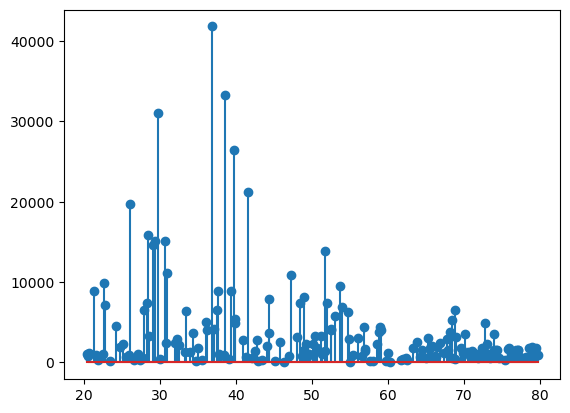

In [52]:
plt.stem(Ti3Bi2_xrds[1], Ti3Bi2_xrds[3])
plt.stem(Ti3Bi_xrds[1], Ti3Bi_xrds[3])

In [45]:
from pymatgen.core.structure import Structure
from pymatgen.io.cif import CifParser
from io import StringIO
from pymatgen.core.structure import Structure
from collections import Counter

def read_in_and_replace_atoms(cif_data): 
    cif_file_like_object = StringIO(cif_data)
    parser = CifParser(cif_file_like_object)
    structure = parser.get_structures()[0]

    element_counts = Counter([site.species_string for site in structure])
    majority_element, minority_element = element_counts.most_common(2)
    element_mapping = {majority_element[0]: "Ti", minority_element[0]: "Bi"}

    # Create a new structure with the elements replaced according to the mapping
    new_sites = []
    for site in structure:
        new_element = element_mapping.get(site.species_string, site.species_string)
        new_sites.append(site.__class__.from_dict(site.as_dict()))
        new_sites[-1].species = {new_element: 1}

    # Create a new structure with the updated sites
    new_structure = Structure.from_sites(new_sites)

    #write the new structure to a cif file
    cif_string = new_structure.to(fmt = 'cif')
    return cif_string

def get_atomic_numbers(cif_data): 
    cif_file_like_object = StringIO(cif_data)
    parser = CifParser(cif_file_like_object)
    structure = parser.get_structures()[0]
    return structure.atomic_numbers


def get_formula(cif_data): 
    cif_file_like_object = StringIO(cif_data)
    parser = CifParser(cif_file_like_object)
    structure = parser.get_structures()[0]
    return structure.formula


In [46]:
Ti3Bi_df['cif'] = Ti3Bi_df['cif'].apply(read_in_and_replace_atoms)
Ti3Bi_df['atomic_numbers'] = Ti3Bi_df['cif'].apply(get_atomic_numbers)
Ti3Bi_df['material_id'] = Ti3Bi_df['cif'].apply(get_formula)

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


In [48]:
Ti3Bi_df

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,counts_dict,length
14,37322,Ti3 Bi1,-0.072985,0.0,Fe3Pt,0.043073,"['Fe', 'Pt']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,221,DiffractionPattern\n$2\Theta$: [23.72127081 33...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 83)",[ 0. 0. 0. 0. ...,"{26: 3, 78: 1}",4
173,25081,Ti6 Bi2,-0.032134,0.0,Ag3Au,0.008414,"['Ag', 'Au']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,194,DiffractionPattern\n$2\Theta$: [17.38599516 25...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{47: 6, 79: 2}",8
115,22033,Ti9 Bi3,-0.309906,0.0,NdNi3,0.003221,"['Nd', 'Ni']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,166,DiffractionPattern\n$2\Theta$: [10.69508605 20...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 83, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{60: 3, 28: 9}",12
23,21268,Ti12 Bi4,-0.292651,0.0,Sn3Pd,0.001153,"['Sn', 'Pd']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,64,DiffractionPattern\n$2\Theta$: [10.12111317 19...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{50: 12, 46: 4}",16
92,22625,Ti15 Bi5,-0.431502,0.0,TbAl3,0.004027,"['Al', 'Tb']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,166,DiffractionPattern\n$2\Theta$: [ 7.36616783 14...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{65: 5, 13: 15}",20


In [49]:
Ti3Bi2_df['cif'] = Ti3Bi2_df['cif'].apply(read_in_and_replace_atoms)
Ti3Bi2_df['atomic_numbers'] = Ti3Bi2_df['cif'].apply(get_atomic_numbers)
Ti3Bi2_df['material_id'] = Ti3Bi2_df['cif'].apply(get_formula)

In [50]:
Ti3Bi2_df

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,counts_dict,length
19,17376,Ti3 Bi2,-0.766125,0.0000,Ba2Bi3,0.000000,"['Ba', 'Bi']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,71,DiffractionPattern\n$2\Theta$: [14.19813572 17...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{56: 2, 83: 3}",5
591,26518,Ti6 Bi4,-0.346087,0.0000,Tb3Ni2,0.010913,"['Ni', 'Tb']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,12,DiffractionPattern\n$2\Theta$: [ 9.67752882 13...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 83, 83, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{65: 6, 28: 4}",10
903,33872,Ti9 Bi6,-3.844539,3.4658,La2O3,0.029604,"['La', 'O']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,12,DiffractionPattern\n$2\Theta$: [ 9.74574958 12...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 83, 83, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{57: 6, 8: 9}",15
332,27058,Ti12 Bi8,-2.354091,0.6267,Er2S3,0.012393,"['Er', 'S']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,62,DiffractionPattern\n$2\Theta$: [11.92649527 16...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{68: 8, 16: 12}",20


In [53]:
#merge the two dataframes into unsolved_compounds_df
unsolved_df = pd.concat([Ti3Bi_df, Ti3Bi2_df])

In [54]:
#save this dataframe to a new folder /home/gridsan/tmackey/cdvae/data/unsolved_compounds
unsolved_df.to_csv('/home/gridsan/tmackey/cdvae/data/unsolved_compounds/test.csv', index = False)

To double check: read the data back in

In [16]:
import pandas as pd 

unsolved_df = pd.read_csv('/home/gridsan/tmackey/cdvae/data/unsolved_compounds/test.csv')

In [17]:
print(unsolved_df['cif'].iloc[0])

# generated using pymatgen
data_Ti3Bi
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   3.75085400
_cell_length_b   3.75085400
_cell_length_c   3.75085400
_cell_angle_alpha   90.00000000
_cell_angle_beta   90.00000000
_cell_angle_gamma   90.00000000
_symmetry_Int_Tables_number   1
_chemical_formula_structural   Ti3Bi
_chemical_formula_sum   'Ti3 Bi1'
_cell_volume   52.77041133
_cell_formula_units_Z   1
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Ti  Fe0  1  0.00000000  0.50000000  0.50000000  1
  Ti  Fe1  1  0.50000000  0.50000000  0.00000000  1
  Ti  Fe2  1  0.50000000  0.00000000  0.50000000  1
  Bi  Pt3  1  0.00000000  0.00000000  0.00000000  1



We now need to create graphs associated with this data. 

In [18]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import copy
import itertools

from pymatgen.core.structure import Structure
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis import local_env

from networkx.algorithms.components import is_connected

from sklearn.metrics import accuracy_score, recall_score, precision_score

from torch_scatter import scatter

from p_tqdm import p_umap

import ast
#import the random function library
import random

import os 

from tqdm.auto import tqdm
tqdm.pandas()

CrystalNN = local_env.CrystalNN(
    distance_cutoffs=None, x_diff_weight=-1, porous_adjustment=False)

from cdvae.common.data_utils import * 

import sys

#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

#read in the number of splits
try:
    num_splits = int(sys.argv[2])
except:
    num_splits = 1

data_dir = '/home/gridsan/tmackey/cdvae/data/unsolved_compounds/'

#load in the data 
test_df = pd.read_csv(data_dir + 'test.csv')
def build_crystal(crystal_str, niggli=True, primitive=False):
    try: 
        """Build crystal from cif string."""
        crystal = Structure.from_str(crystal_str, fmt='cif')

        if primitive:
            crystal = crystal.get_primitive_structure()

        if niggli:
            crystal = crystal.get_reduced_structure()

        canonical_crystal = Structure(
            lattice=Lattice.from_parameters(*crystal.lattice.parameters),
            species=crystal.species,
            coords=crystal.frac_coords,
            coords_are_cartesian=False,
        )
        # match is gaurantteed because cif only uses lattice params & frac_coords
        # assert canonical_crystal.matches(crystal)
        return canonical_crystal
    except: 
        return None 


def build_crystal_graph(crystal, graph_method='crystalnn'):
    try: 
        """
        """

        if graph_method == 'crystalnn':
            crystal_graph = StructureGraph.with_local_env_strategy(
                crystal, CrystalNN)
        elif graph_method == 'none':
            pass
        else:
            raise NotImplementedError

        frac_coords = crystal.frac_coords
        atom_types = crystal.atomic_numbers
        lattice_parameters = crystal.lattice.parameters
        lengths = lattice_parameters[:3]
        angles = lattice_parameters[3:]

        assert np.allclose(crystal.lattice.matrix,
                        lattice_params_to_matrix(*lengths, *angles))

        edge_indices, to_jimages = [], []
        if graph_method != 'none':
            for i, j, to_jimage in crystal_graph.graph.edges(data='to_jimage'):
                edge_indices.append([j, i])
                to_jimages.append(to_jimage)
                edge_indices.append([i, j])
                to_jimages.append(tuple(-tj for tj in to_jimage))

        atom_types = np.array(atom_types)
        lengths, angles = np.array(lengths), np.array(angles)
        edge_indices = np.array(edge_indices)
        to_jimages = np.array(to_jimages)
        num_atoms = atom_types.shape[0]

        return frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms
    except: 
        return None
    
data_frames = {'test': test_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    sub_df = df.iloc[start_index:end_index].copy()
    sub_crystals = sub_df['cif'].progress_apply(build_crystal)
    sub_graphs = sub_crystals.progress_apply(build_crystal_graph)

    materials_ids = sub_df['material_id'].values

    #make a dictionary using the materials_ids as keys and the graphs as values
    graph_dict = dict(zip(materials_ids, sub_graphs))

    #save the dictionary to a file
    torch.save(graph_dict, data_dir + '{}_{}.pt'.format(name, worker_num))
    
    print('Saved {}_{}.pt'.format(name, worker_num))

  0%|          | 0/9 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/9 [00:00<?, ?it/s]

Saved test_0.pt


Finally, we need to prepare the psueod-voight data. Because got some nice peak locations and intensities, we can actually control the pseudo-voight shape and don't need to add noise. 

In [55]:
import pandas as pd
import numpy as np
import argparse
import os
import random
import torch

try:
    # Argument parsing
    parser = argparse.ArgumentParser(description='Parallel XRD Simulation')
    parser.add_argument('--n_workers', type=int, help='Total number of workers')
    parser.add_argument('--worker_num', type=int, help='Current worker number (0-indexed)')
    args = parser.parse_args()

    n_workers = args.n_workers
    worker_num = args.worker_num
except:
    n_workers = 1
    worker_num = 0
    
data_dir  = '/home/gridsan/tmackey/cdvae/data/unsolved_compounds/'
test_path = os.path.join(data_dir, 'test.csv')

test_df = pd.read_csv(test_path)

dataframes = {'test': test_df}

for name, data in dataframes.items():
    data['xrd_peak_locations'] = data['xrd_peak_locations'].apply(
        lambda x: [float(i) for i in x.strip('[]').split(',')]
    )

    #make sure we can read in the diffraction patterns
    data['xrd_peak_intensities'] = data['xrd_peak_intensities'].apply(
        lambda x: [float(i) for i in x.strip('[]').split(',')]
    )

def caglioti_fwhm(theta, U, V, W):
    """
    Calculate the FWHM using the Caglioti formula.
    theta: float, the angle in degrees
    U, V, W: Caglioti parameters
    """
    rad_theta = np.radians(theta / 2)  # Convert theta to radians
    return (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5

def pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd=0.0):
    """
    Pseudo-Voigt function using Caglioti FWHM.
    x: array-like, the independent variable
    center: float, the center of the peak
    amplitude: float, the height of the peak
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    fwhm = caglioti_fwhm(center, U, V, W)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma for Gaussian
    # Generate random noise from a normal distribution
    noise = np.random.normal(0, noise_sd)

    noisy_percentage = (100 + noise_sd) / 100 
    #print("noisy_percentage is ", noisy_percentage)

    #multiply the amplitude by the noisy percentage 
    amplitude = amplitude * noisy_percentage
    
    lorentzian = amplitude * (fwhm**2 / ((x - center)**2 + fwhm**2))
    gaussian = amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))
    return eta * lorentzian + (1 - eta) * gaussian

def superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=0.0):
    """
    Superimpose multiple pseudo-Voigt functions using Caglioti FWHM.
    x: array-like, the independent variable
    xy_merge: nx2 array, first column is peak locations, second column is intensities
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    total = np.zeros_like(x)
    for row in xy_merge:
        center, amplitude = row
        total += pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd)
    total = total / max(total)
    return total

# Function to simulate XRD for each row
def simulate_pv_xrd_for_row(row_tuple, U, V, W):
    index, row = row_tuple  # Unpack the tuple

    x = np.arange(5, 90, 0.010)
    eta = 0  # Fraction of Lorentzian component (common for all peaks)

    # Combine peak locations and intensities into a single array
    xy_merge = np.column_stack((row['xrd_peak_locations'], row['xrd_peak_intensities']))

    sim_xrd = superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=noise)

    return sim_xrd

def apply_simulation(data, U, V, W, worker_num, n_workers, peak_shape = 0):
    # Split data for the current worker
    chunk_size = len(data) // n_workers
    start_idx = worker_num * chunk_size
    end_idx = None if worker_num == n_workers - 1 else start_idx + chunk_size # Last worker gets the rest
    worker_data = data.iloc[start_idx:end_idx]

    print("Worker", worker_num, "processing", len(worker_data), "rows")
    print("start index:", start_idx, "end index:", end_idx)

    # Process using a list comprehension
    results = [simulate_pv_xrd_for_row((idx, row), U, V, W) for idx, row in worker_data.iterrows()]
    
    #turn the list of numpy arrays into a numpy array
    results = np.stack(results)

    tensor = torch.from_numpy(results).float()

    tensor = tensor.reshape(tensor.shape[0], 1, tensor.shape[1])

    data_dict = {}
    for i in range(len(worker_data)):
        key = worker_data['material_id'].iloc[i]
        data_dict[key] = tensor[i]

    return data_dict

noise = 0 #this noise corresponds roughly to the effects something like preferred orientation might have on the diffraction pattern. set to 0 for now
peak_shapes = [(0.05, -0.06, 0.07)]

for name, data in dataframes.items():
    # Assuming peak_shapes is defined elsewhere in your code
    for peak_shape, (U, V, W) in enumerate(peak_shapes): 
        sim_pv_xrd_intensities_dict = apply_simulation(data, U, V, W, worker_num, n_workers, peak_shape) #this going to be a n x 8192 array 

        # Save results as a numpy array
        output_filename = data_dir + f'{name}_sim_pv_xrd_intensities_{peak_shape}_worker_{worker_num}.pt'
        torch.save(sim_pv_xrd_intensities_dict, output_filename)
        print("Saved to {}".format(output_filename))

print("Simulation completed for worker number:", worker_num)

usage: ipykernel_launcher.py [-h] [--n_workers N_WORKERS]
                             [--worker_num WORKER_NUM]
ipykernel_launcher.py: error: unrecognized arguments: --f=/home/gridsan/tmackey/.local/share/jupyter/runtime/kernel-v2-472114f7FE2PUh5W7s.json


Worker 0 processing 9 rows
start index: 0 end index: None
Saved to /home/gridsan/tmackey/cdvae/data/unsolved_compounds/test_sim_pv_xrd_intensities_0_worker_0.pt
Simulation completed for worker number: 0


In [56]:
import pandas as pd
import numpy as np
import torch
train_dict = torch.load('/home/gridsan/tmackey/cdvae/data/unsolved_compounds/test_sim_pv_xrd_intensities_0_worker_0.pt')

In [57]:
import matplotlib.pyplot as plt 

key is Ti3 Bi1
key is Ti6 Bi2
key is Ti9 Bi3
key is Ti12 Bi4
key is Ti15 Bi5
key is Ti3 Bi2
key is Ti6 Bi4
key is Ti9 Bi6
key is Ti12 Bi8


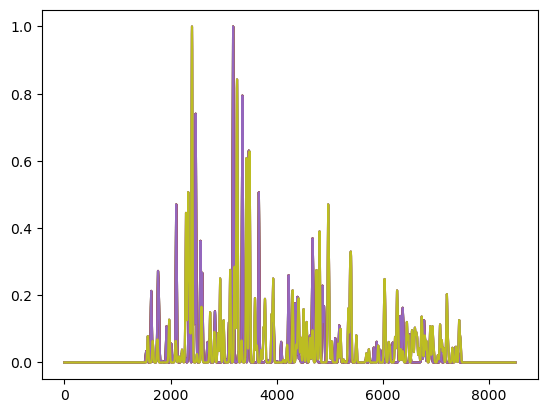

In [63]:
#plot the diffraction pattern for Ti3Bi2
for key_index in range(0, 9):
    print('key is', list(train_dict.keys())[key_index])
    plt.plot(train_dict[list(train_dict.keys())[key_index]][0].numpy())